# Atmospheric flux operator

In [1]:
import pyarts
import numpy as np
import matplotlib.pyplot as plt

## Initialize the operator

See [AtmosphericFlux](pyarts.recipe.rst#pyarts.recipe.AtmosphericFlux).

In [2]:
fop = pyarts.recipe.AtmosphericFlux(species=["H2O-161", "O2-66", "N2-44", "CO2-626", "O3-XFIT"],
                                    remove_lines_percentile={"H2O": 70})

## Get the atmosphere (optional)
The atmosphere is the full atmospheric field of ARTS as a dictionary,
which is likely more than you wish to change.  You may change only part
of the atmosphere by simply creating a dictionary that only contains the
fields that you want to change.

In [3]:
atm = fop.get_atmosphere()

## Get the profile flux for the given `atm`
Passing `atm` is optional, if not passed the operator will use the current atmosphere,
which is the atmosphere that was set with the last call to `__call__`, or the constructor
default if no call to `__call__` has been made.

In [4]:
solar, thermal, altitude = fop(atmospheric_profile=atm)

## Plot

Text(0.5, 1.0, 'Thermal flux')

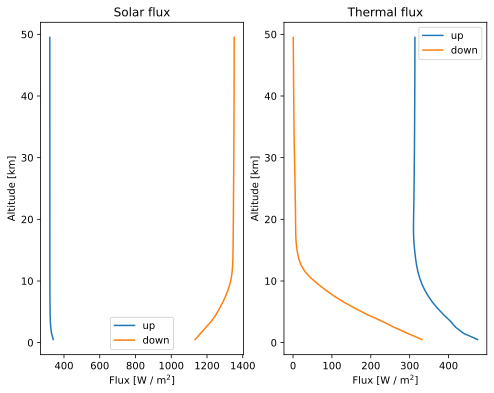

In [5]:
plt.figure(1, figsize=(8, 6))
plt.clf()
plt.subplot(121)
plt.plot(solar.up, altitude/1e3)
plt.plot(solar.down, altitude/1e3)
plt.legend(["up", "down"])
plt.ylabel("Altitude [km]")
plt.xlabel("Flux [W / m$^2$]")
plt.title("Solar flux")

plt.subplot(122)
plt.plot(thermal.up, altitude/1e3)
plt.plot(thermal.down, altitude/1e3)
plt.legend(["up", "down"])
plt.ylabel("Altitude [km]")
plt.xlabel("Flux [W / m$^2$]")
plt.title("Thermal flux")